# Exercise 5: Probability and Bayesian Learning

* Write solutions in a file named `hw5.pdf`.
* Show your work clearly and provide the intermediate steps.
* You may use Python to carry out numerical calculations.

### Guidelines for Programming Exercises

* Complete the required functions in `hw5.py`.
* All functions must operate only on the arguments they receive.
* Do not rename or change function signatures.
* Write efficient, vectorized code whenever poissible. No individual cell should have a runtime of more than 5 minutes on a standard architecture.
* You are allowed to use functions and methods from the Python standard library, `numpy`, and `pandas` only.
* Your code must run without errors.
* The file will be imported directly by the auto-grader.
* Do not execute code at import time.
* Do not read or write any files inside `hw5.py`.
* This notebook is for guidance and self-testing only. You may add code and text to it, but it will not be tested.


### Submission Guidelines

* Submit a zip file that contains:
    - `hw5.py`
    - `hw5.ipynb` with your IDs in the signature line below and any tests you added (will not be checked)
    - `hw5.pdf`
* Use a zip filename that contains your ID(s), for example `hw5_123456789.zip` or `hw5_123456789_987654321.zip`.
* Place the files at the **top level of the zip**, not inside nested folders.


---
---

## Please sign that you have read and understood the instructions:

### *** YOUR IDs HERE ***
# ID1: 206630915
# ID2: 208004416
---
---


# Part 1: Theoretical Exercise (18 pts)
## Maximum Likelihood Estimation and Confidence Intervals

The Poisson distribution is a discrete probability distribution over the non-negative integers with a single rate parameter $\lambda>0$ and PMF:
$$
\Pr[X=k] = \frac{\lambda^k e^{-\lambda}}{k!}
$$
This distribution is useful in modeling the number of event occurrences in a fixed time interval when the probability of an event occurrence does not depend on the time since the last event. For example, the number of jobs received by a server in a one-hour interval. 

The Poisson rate, $\lambda$, is the expected number of events in one time interval.
Consequently, the expectation and variance of a $\mathrm{Pois}(\lambda)$ random variable are both $\lambda$.


In questions 1-5 below you will derive a procedure for computing a maximum likelihood estimate (MLE) and confidence interval (CI) for the Poisson rate $\lambda$. Assume you are given a set of values $D = \{x_1,\ldots,x_n\}$ that are assumed to be sampled from independent $\mathrm{Pois}(\lambda)$ random variables $X_1,\ldots,X_n$.

1. **(2 pts)** Write the **log-likelihood** function $\ell(\lambda;D)$. Use the natural base ($\ln$).
2. **(2 pts)** Use $\ell(\lambda;D)$ to find an expression for the MLE $\hat{\lambda}$ of $\lambda$.

3. **(3 pts)** Consider $\hat{\lambda}$ as a random variable whose randomness stems from the randomness in $X_1,\ldots,X_n$.
Write an expression for the mean $\mathbb E[\hat{\lambda}]$ and the variance $\mathrm{Var}[\hat{\lambda}]$ as a function of $n$ and $\lambda$.

4. **(5 pts)** Apply the *central limit theorem (CLT)* to derive an expression for the asymptotic 95% confidence interval (CI) for $\lambda$ around the estimated $\hat\lambda$. Recall that the CLT implies that the **standardized** value of $\hat\lambda$ approaches a normal distribution as the number of data points goes to infinity:
$$
\begin{align}
\frac{\hat{\lambda} - \mathbb E[\hat{\lambda}]}{\sqrt{\mathrm{Var}[\hat{\lambda}]}} \sim \mathcal N(0,1). 
\end{align}
$$
$~~~~~~$ Your expressions for the lower and upper boundaries of the 95% CI should be specified as functions of $\hat\lambda$, $n$, and the inverse Gaussian CDF $\Phi^{-1}$. 

5. **(2 pts)** Evaluate the MLE $\hat\lambda$ and the $95\%$ CI for $\lambda$ using the data specified in the cell below.

In [39]:
D = [3, 3, 3, 6, 4, 7, 5, 1, 3, 1, 2, 2, 6, 0, 2, 1, 5, 3, 6, 4, 4, 4,
       5, 5, 2, 8, 3, 6, 5, 4, 4, 5, 5, 2, 3, 4, 0, 3, 2, 6, 3, 4, 1, 4,
       4, 2, 5, 1, 3, 2]

6. **(4 pts)** This question deals with time-dependent Poisson random variables and exponential waiting time.
Consider a scenario in which jobs are received by a server at some constant rate per unit of time.
Say that the average rate of jobs per second is $\bar{\lambda}$.
We model the number of jobs received in a time period of $t$ seconds using a Poisson random variable with rate
$\lambda := \bar{\lambda} t
$.
For example, the number of jobs received by the server in one hour is a $\mathrm{Pois}(3600\bar\lambda)$ random variable.

$~~~~~~~$ Let $Y$ be the time until the first job is received. Show that $Y$ has an exponential distribution.

$~~~~~~~$ Namely, that there is some some $\nu > 0$ such that the PDF of $Y$ is of the form
$$
f_{Y}(y) = \nu e^{-\nu \ y},\qquad y \geq 0, 
$$
$~~~~~~~$ Express $\nu$ in terms of $\bar{\lambda}$. 

$~~~~~~~$ Hint: use the fact that $Y > t$ iff the number of jobs received in the first $t$ seconds is 0.

# Part 2: Coding Assignment (82 pts)

In this coding assignment, you will implement several Bayesian classifiers for **three different datasets**.

The code cell below sets up the libraries for this analysis.

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# make the notebook automatically reload external python modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. The number of goals in a football match (12 pts)

In this question, we analyze data for goals in the regular UEFA Champions League 2025-6 season (not including playoff games).
We will model the number of goals in each match using the Poisson random variable.

### Loading and exploring the data (0 pts; nothing to submit)

The code cell below reads the data from a file, does some basic preprocessing and plots a histogram of the number of goals per match.

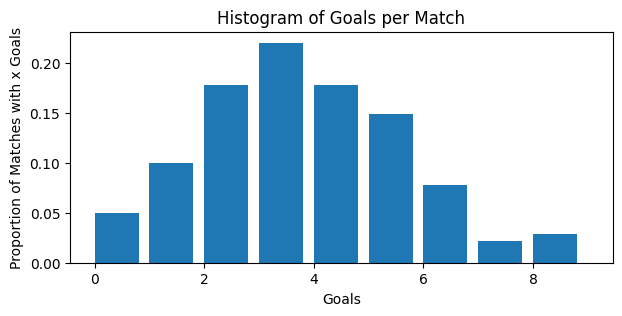

In [48]:
# Loads UEFA Champions League match data from the 2025-6 season:
df_champs = pd.read_csv("data/champs_2025-6.csv").dropna()

# Extract home and away goals from score column
goals = df_champs['score'].str.extract(r'(\d+).(\d+)')
df_champs['totalGoals'] = goals.astype(float).sum(axis=1, min_count=2)

# Present relevant columns
df_champs.filter(items=['home_team', 'away_team', 'Date', 'score', 'totalGoals']).head()

# Plot the histogram of goals per match
max_goals = df_champs['totalGoals'].max()
plt.figure(figsize=(7,3))
plt.hist(df_champs['totalGoals'], bins = np.arange(0, max_goals + 1 ,1), width=0.8, density=True)
plt.xlabel('Goals')
plt.ylabel('Proportion of Matches with x Goals')
plt.title("Histogram of Goals per Match")
plt.show()

### Log of point mass function (3 pts)

**Complete the function `poisson_log_pmf` in `hw5.py`**. 
This function computes the (natural) log of the PMF of a Poisson distribution with a given rate ($\lambda$) for a given event count ($k$) or an array of event counts (in which case the function returns an array of log PMF values). You may use the function `math.factorial` from the `math` library to compute the factorial of a number. 

### Poisson MLE (3 pts)

**Complete the function `poission_analytic_mle` in `hw5.py`**. This function computes the MLE for the Poisson rate parameter using the expression you derived for $\hat\lambda$ in the theoretical exercise above.

The code cell below computes the MLE on the dataset of goals per match.

In [49]:
from hw5 import poisson_log_pmf, poission_analytic_mle

X = df_champs['totalGoals'].values.flatten()
lambda_mle = poission_analytic_mle(X)

### Confidence interval (3 pts)

**Complete the function `poission_confidence_interval` in `hw5.py`**. This function computes a $(1-\alpha)$ confidence interval (CI) around an estimated $\hat\lambda$ using the expression you derived in the theoretical exercise above. You may use `statistics.NormalDist().inv_cdf` from the Python standard library to compute the inverse of the standard normal CDF function ($\Phi^{-1}$).

The code cell below computes two CIs around the MLE you computed above:
one corresponding to 95% confidence ($\alpha=0.05$) and one corresponding to 99% confidence ($\alpha=0.01$).


In [52]:
from hw5 import poission_confidence_interval

[lower_bound005, upper_bound005] = poission_confidence_interval(lambda_mle,X.shape[0], alpha=0.05)
[lower_bound001, upper_bound001] = poission_confidence_interval(lambda_mle,X.shape[0], alpha=0.01)

print(f"95% CI for lambda: ({lower_bound005}, {upper_bound005})")
print(f"99% CI for lambda: ({lower_bound001}, {upper_bound001})")

95% CI for lambda: (3.1132622257954714, 3.7236172068286417)
99% CI for lambda: (3.0173685083425856, 3.8195109242815275)


### Log likelihood (3 pts)

** Complete the function `get_poisson_log_likelihoods` in `hw5.py`**. This function computes the log likelihoods of a list of rate values ($\lambda$) given a dataset `X` comprised of a list of values (number of goals per match).

The code cell below uses this function to validate that the MLE you got above indeed corresponds to the maximum log likelihood.

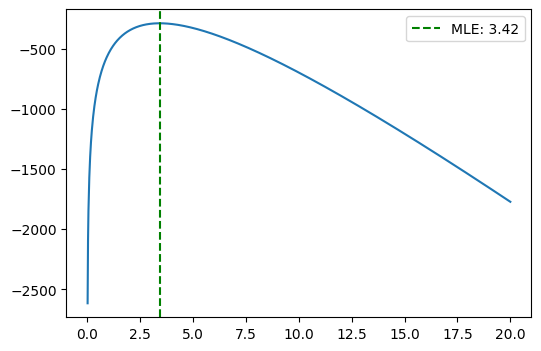

In [53]:
from hw5 import get_poisson_log_likelihoods
potential_rates = np.linspace(0.01, 20, num=1000)

plt.figure(figsize=(6,4))
plt.plot(potential_rates, get_poisson_log_likelihoods(X, potential_rates))
plt.axvline(x=lambda_mle, linestyle='--', c='g', label=f"MLE: {lambda_mle:.2f}")
plt.legend()
plt.show()

The code cell below uses the `poisson_log_pmf` function to compute the PMF of a Poisson distribution with the rate you received as MLE.
This PMF is then compared to the histogram of goals per game in the dataset.
This comparison allows you to visually assess the fit of the (best fit) Poisson model to the data.

**Food for thought:** It is rare to see more than eight goals per match. In fact, it happened once in the UEFA Champions League 2025-6 regular season. Can you provide an estimate of the probability that more than eight goals ($\geq 9$) would be scored in one game based on the model you fit to your data?

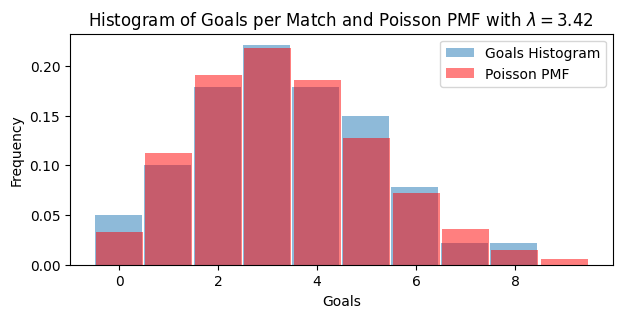

In [54]:
k_vals = np.arange(0, max_goals+1,1)
poisson_pmf = np.exp(poisson_log_pmf(k_vals, lambda_mle))

# align the histogram to the center of the bins:
plt.figure(figsize=(7,3))
plt.hist(X, bins=k_vals-0.5, density=True, align='mid', width=0.95, label='Goals Histogram', alpha=0.5)

plt.bar(k_vals, poisson_pmf, label='Poisson PMF', color='red', width=0.95, alpha=0.5)
plt.legend()

plt.title(rf"Histogram of Goals per Match and Poisson PMF with $\lambda=${lambda_mle:.2f}")
plt.ylabel('Frequency')
plt.xlabel('Goals')
plt.show()

## 2. Conditional independence (8 pts)

The purpose of this question is to define a probability distribution over three binary random variables ($X, Y, C$)
such that they satisfy the following properties:  
1. The marginal probabilities of the three variables are specified as follows:  
    * $\Pr[X=0] = 0.3 ~~ ; ~~  \Pr[X=1] = 0.7$
    * $\Pr[Y=0] = 0.3 ~~ ; ~~  \Pr[Y=1] = 0.7$
    * $\Pr[C=0] = 0.5 ~~ ; ~~  \Pr[C=1] = 0.5$
2. $X$ and $Y$ are not (marginally) independent
3. $X$ and $Y$ are conditionally independent given $C$: $~~X \perp\!\!\!\perp Y\ |\ C$

Recall that $X$ and $Y$ are conditionally independent given $C$ if and only if for all $x,y,c$ we have:
$$
\Pr[X=x,Y=y|C=c] ~=~ \Pr[X=x|C=c]\ \Pr[Y=y|C=c] ~,
$$

where $\Pr[A=a|B=b]=\frac{\Pr[A=b,B=b]}{\Pr[B=b]}$.

**Complete the Python dictionaries `X_Y_C`, `X_Y`, `X_C`, and `Y_C` in class `conditional_independence` in `hw5.py`**.
These dictionaries should specify the appropriate joint probabilities such that random variables $X, Y, C$
satisfy the conditions above.
All dictionaries should specify valid probability distributions,
meaning that they contain non-negative values that sum to one.
Moreoves, all distributions should be consistent with the complete joint probability distribution you define in `X_Y_C`.
This includes the marginal distributions for $X, Y, C$, which are fixed in the dictionaries `X`, `Y`, and `C`.

**Complete the member functions `is_X_Y_dependent`, `is_X_Y_given_C_independent` in class `conditional_independence` in `hw5.py`**.
These functions check that requirements (2) and (3) above are satisfied.

The code cell below applies these two functions to confirm that requirements (2) and (3) above are satisfied.
Note that this does not check the consistency of all dictionaries, as required above.
So, you should make sure of this separately.

In [55]:
from hw5 import conditional_independence

print(conditional_independence().is_X_Y_dependent())
print(conditional_independence().is_X_Y_given_C_independent())

True
True


## The Randomammal dataset

Questions 3 and 4 below involve data regarding an **imaginary animal called the Randomammal**.
Scientists observed the randomammals' habitat for 1000 days to try to determine the conditions under which randomammals are active (or not).
For each of the 1000 days, the scientists recorded the temperature and the humidity and whether a randomammal was spotted or not.
Thus, our dataset contains two features (**Temperature**, **Humidity**) alongside a binary class label (**Spotted**) for each of the 1000 days in the study.

The code cell below loads the train and test data sets into a pandas dataframe and converts them into numpy arrays.
We then visualize the training data using a scatterplot where *x*=Temperature, *y*=Humidity and the class label is represented by color.

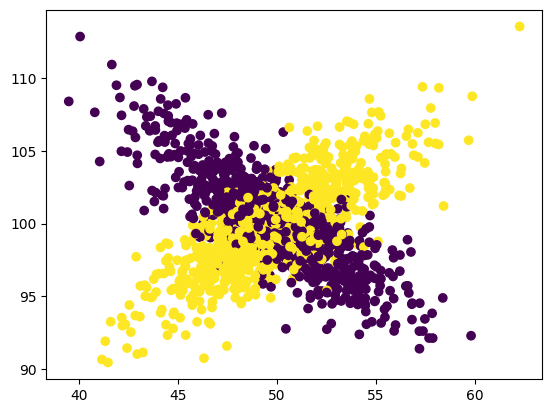

In [56]:
# Load the train and test set into a pandas dataframe and convert them into a numpy array.
# The columns order: ['Temp', 'Humidity', 'Spotted']
train_set = pd.read_csv('data/randomammal_train.csv').values
test_set = pd.read_csv('data/randomammal_test.csv').values

plt.scatter(x=train_set[:, 0], y=train_set[:, 1], c=train_set[:, 2])


## 3. Bob's normal naive Bayes classifier (24 pts)

**Bob** is ahe well-known scientist studying randomammals and he prefers simple models.
So, he wants to use a Naive Bayes classifier to predict Randomammals appearances from temperature and humidity.
Note that it is unlikely that temperature and humidity are independent,
regardless of whether we condition on randomammal appearance or not.
However, as we discussed in class, Naive Bayes classifiers can be effective
even when the conditional independence assumption is not strictly satisfied.
Recall that a Naive Bayes classifier for two features makes the following assumption: 
$$ 
f_{X|Y=y}(x_1,x_2) = f_{X_1|Y=y}(x_1)\ f_{X_2|Y=y}(x_2)
$$

Bob wishes to fit each of the four feature-specific class conditionals, $f_{X_1|Y=0}, f_{X_2|Y=0}, f_{X_1|Y=1}$, and $f_{X_2|Y=1}$,
using univariate normal distributions with different means ($\mu$) and variances ($\sigma^2$).

### Univariate normal PDF (4 pts)

**Complete the function `normal_pdf` in `hw5.py`**. This function computes the PDF of a univariate normal distribution with given mean and standard deviation at a given value ($x$) according to the expression:
$$
f(x;\mu,\sigma) = \frac{1}{\sqrt{2\pi\sigma^2}} \cdot e ^{-\frac{(x - \mu)^2}{2\sigma^2}}
$$

The code cell below imports this function. You may add code to test your implementation of `normal_pdf`.

In [57]:
from hw5 import normal_pdf

### The naive Bayes probability distributions (15 pts)

The `NaiveNormalClassDistribution` class maintains all the infromation required for modeling the distribution of the features for a given value of the class label (0 or 1 in our case) under the naive Bayes normal model.
The constructor of this class receives a class label and is already implemented.
All other member functions assume this value of the class label.

**Complete the member functions listed below of the `NaiveNormalClassDistribution` class in `hw5.py`**. 
* `fit`  receives a dataset and estimates the class prior and a separate normal distribution for each feature (conditioned on the class label).
* `get_prior` returns the prior probability of the class, as computed by `fit`.
* `get_instance_likelihood` returns the probability of a given featrure vector **conditioned on** the class label
(as implied by the naive Bayes model).
* `get_instance_joint_prob` returns the probability of a given featrure vector **jointly with** the class label
(as implied by the naive Bayes model).

Your implementation should work with any number of features; don't strictly assume two features as in our dataset.

The code cell below fits a Naive Bayes model to the training set using two `NaiveNormalClassDistribution` objects
for class lables 0 and 1.
It then computes the joint probability of the first test sample under both class labels.

In [58]:
from hw5 import NaiveNormalClassDistribution

# Build and fit a NaiveNormalClassDistribution for each class label
naive_normal_CD_0 = NaiveNormalClassDistribution(0)
naive_normal_CD_0.fit(train_set)
naive_normal_CD_1 = NaiveNormalClassDistribution(1)
naive_normal_CD_1.fit(train_set)

# Report the joint probability of the 1st test sample under both class labels
x_test = test_set[1, :-1]
print(f"Test point: {x_test} has joint probability {naive_normal_CD_0.get_instance_joint_prob(x_test):.4f} for class 0")
print(f"Test point: {x_test} has joint probability {naive_normal_CD_1.get_instance_joint_prob(x_test):.4f} for class 1")

Test point: [43.04295116 90.82977687] has joint probability 0.0000 for class 0
Test point: [43.04295116 90.82977687] has joint probability 0.0000 for class 1


### The MAP classifier (5 pts)

The `MAPClassifier` class implements a classifier that predicts class labels ($y$) for feature vectors ($x$)
using the maximum a-posteriori (MAP) rule.
Each object in this class holds a (fitted) `ClassDistribution` object for each class label (0 and 1).
These objects are used to conduct the MAP predictions.

In this question you will use a `NaiveNormalClassDistribution` object you implemented above
and in Question 4 you will use a different class object.

**Complete the constructor (`__init__`) and member function `predict` of the `MAPClassifier` class in `hw5.py`**.

The code cell below uses the two  `NaiveNormalClassDistribution` objects fitted above
to construct a  `MAPClassifier` object.
This `MAPClassifier` object is then used to predict the class label for the first test sample.

In [59]:
from hw5 import MAPClassifier
naive_normal_classifier = MAPClassifier(naive_normal_CD_0, naive_normal_CD_1)

print(f"MAP Classifier predicts class {naive_normal_classifier.predict(x_test)} for test point {x_test}")

MAP Classifier predicts class 0 for test point [43.04295116 90.82977687]


## 4. Alice's bivariate normal classifier (24 pts)

**Alice**, Bob's colleague, suspects that Bob's Naive Bayes classifier might underperform on the randomammal data. 
She proposes using a Bayes classifier that uses a (general) bivariate normal distribution for the class conditional distributions.
This approach adds one parameter to each of the two class conditionals corresponding to the covariance between the two features (given the class label). Alice argues that there is sufficient data to support estimation of the two additional parameters without overfitting.

### Multivariate normal PDF (4 pts)

**Complete the function `multi_normal_pdf` in `hw5.py`**. This function computes the PDF of a multivariate normal distribution with given mean vector ($\mu\in \mathbb{R}^p$) and a covariance matrix ($\Sigma\in \mathbb{R}^{p\times p}$) at a given value ($x\in \mathbb{R}^p$) according to the following function:
$$
(2\pi)^{-\frac{p}{2}} \mathrm{det}(\Sigma )^{-\frac{1}{2}} \cdot e ^{-\frac{1}{2}(x-\mu)^T \Sigma ^ {-1} (x - \mu) }
$$

The code cell below imports this function. You may add code to test your implementation of `multi_normal_pdf`.

In [62]:
from hw5 import multi_normal_pdf

### The full Bayes probability distributions (15 pts)


The `MultiNormalClassDistribution` class maintains all the infromation required for modeling the distribution of the features for a given value of the class label (0 or 1 in our case) under the full Bayes model with multivariate normal conditionals.
This class is similar to the `NaiveNormalClassDistribution` class and has the same method functions.
In this class, fitting is done by estimating a multivariate normal distribution over all features jointly
(our data has two features, but your code should not assume this).
The covariance matrix should be estimated using the *sample covariance matrix*, as seen in class.

**Complete the member functions of the `MultiNormalClassDistribution` class in `hw5.py`**.

The code cell below fits a bivariate normal distributions to the training set using two `MultiNormalClassDistribution` objects
for class lables 0 and 1.
It then uses these objects to construct a `MAPclassifier` object and predict the class label for the first test sample.

In [61]:
from hw5 import MultiNormalClassDistribution

# Build and fit a MultiNormalClassDistribution for each class.
multi_normal_CD_0 = MultiNormalClassDistribution(0)
multi_normal_CD_0.fit(train_set)
multi_normal_CD_1 = MultiNormalClassDistribution(1)
multi_normal_CD_1.fit(train_set)

# Use these distributions to build a MAPClassifier.
multi_normal_classifier = MAPClassifier(multi_normal_CD_0, multi_normal_CD_1)

print(f"Test point: {x_test} has joint probability {multi_normal_CD_0.get_instance_joint_prob(x_test):.4f} for class 0")
print(f"Test point: {x_test} has joint probability {multi_normal_CD_1.get_instance_joint_prob(x_test):.4f} for class 1")
print(f"MAP Classifier predicts class {multi_normal_classifier.predict(x_test)} for test point {x_test}")

Test point: [43.04295116 90.82977687] has joint probability 0.0000 for class 0
Test point: [43.04295116 90.82977687] has joint probability 0.0002 for class 1
MAP Classifier predicts class 1 for test point [43.04295116 90.82977687]


### Comparing Alice's and Bob's models (5 pts)

We now wish to compare the two classifiers on the test set to see which approach was better.

**Complete the function `compute_accuracy` in `hw5.py`**. This function computes the accuracy of a given (MAP) classifier on a (test) dataset.

The code cell below applies this function to the two `MAPclassifier` objects trained according to Bob's and Alice's approaches on the same test data.
It then plots the estimated accuracy of each classifier in a bar plot.

Text(0, 0.5, 'Accuracy')

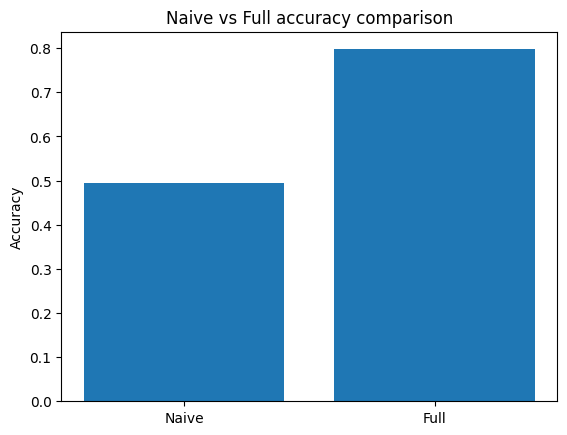

In [63]:
from hw5 import compute_accuracy

# Compute the accuracy of Bob's and Alice's models
naive_accuracy = compute_accuracy(test_set, naive_normal_classifier)
full_accuracy = compute_accuracy(test_set, multi_normal_classifier)
naive_accuracy, full_accuracy

# Bar plot of accuracy of each model side by side.
plt.bar(x=['Naive', 'Full'], height=[naive_accuracy, full_accuracy])
plt.title("Naive vs Full accuracy comparison")
plt.ylabel("Accuracy")

## 5. A naive Bayes predictor for breast cancer (14 pts)

In this question, we train a breast cancer predictor on the Breast Cancer Dataset described [here](https://archive.ics.uci.edu/ml/datasets/breast+cancer).
This predictor is based on a naive Bayes classifier that uses discrete features and *Laplace smoothing* (as you see in the recitation).

The code cell below loads the training and test sets for this analysis.

In [ ]:
# Load the train and test set into a pandas dataframe and convert them into a numpy array.
train_set = pd.read_csv('data/breast_trainset.csv').values
test_set = pd.read_csv('data/breast_testset.csv').values

Recall from the recitation that the feature-specific class conditional probability in this model is estimated from the training data ($D$) using the formula

$$ \Pr[X_j=a | Y=y] = \frac{n_{j,a,y} + 1}{n_y + |A_j|}~,$$
where:
* $D_y = \{(x,y')\in D\ |\  y'=y\}$.
* $n_y = |D_y|$.
* $n_{j,a,y}= |\{(x,y)\in D_y\ |\ x_j=a \}$|.
* $A_j$ is the set of poissible values for the $j$-th feature.

The likelihood in this model is computed as follows: 
$$ P(x| Y=j) = \prod\limits_{t=1}^{p}\Pr[X_t=x_t|Y=j]~. $$

The predicted class is then obtained by the MAP rule:
$$\hat{y}(x) ~~=~~ \arg\!\max\limits_{j} \{\  \pi_j \cdot P(x | Y=j)\ \}~.$$


**Complete the member functions of the `DiscreteNBClassDistribution` class in `hw5.py`**.

The `DiscreteNBClassDistribution` class maintains all the infromation required for modeling the distribution of the features for a given value of the class label (0 or 1 in our case) under the naive Bayes model with discrete features.
This class is similar to the `NaiveNormalClassDistribution` class and has the same method functions.
In this class, fitting is done by estimating the feature-specific discrete class conditional probabilities
using Laplace smoothing, as described above.

The code cell below fits discrete class conditionals to the training set using two `MultiNormalClassDistribution` objects
for class lables 0 and 1.
It then uses these objects to construct a `MAPClassifier` object and assesses its accuracy on the test set.

In [65]:
from hw5 import DiscreteNBClassDistribution

# Build and fit a DiscreteNBClassDistribution for each class label
discrete_naive_CD_0 = DiscreteNBClassDistribution(0)
discrete_naive_CD_0.fit(train_set)
discrete_naive_CD_1 = DiscreteNBClassDistribution(1)
discrete_naive_CD_1.fit(train_set)

# Use these distributions to build a MAPClassifier and compute its accuracy
discrete_naive_classifier = MAPClassifier(discrete_naive_CD_0, discrete_naive_CD_1)
discrete_naive_accuracy = compute_accuracy(test_set, discrete_naive_classifier)
discrete_naive_accuracy

0.7368421052631579